# Part B:- Data Aquisition

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data loading using json

In [234]:
import json

In [235]:
a = open(r"C:\Users\Ibhrahim ansari\Desktop\Data preprocessing\project 1\transactions_messy_80.json","r")
data = a.read()
json_df = json.loads(data)

json_data = pd.json_normalize(json_df)
json_data

,customer_id,purchase_amount,payment_method,transaction_date
0,101,None,upi,March 10 2023
1,102,1000,Cash,March 10 2023
2,103,2000,Cash,2024-01-01
3,104,7000,None,01/02/2024
4,305,9000,None,March 10 2023
...,...,...,...,...
75,176,1000,Cash,2024-01-01
76,177,9000,UPI,March 10 2023
77,178,1000,Card,2024-01-01
78,179,5000,Card,15-03-24


## Data loading using csv

In [236]:
csv_data = pd.read_csv(r"C:\Users\Ibhrahim ansari\Desktop\Data preprocessing\project 1\customers_messy_80.csv")
csv_data

,customer_id,name,age,gender,city,join_date
0,101,Riya,thirty,F,Surat,15-03-24
1,102,NaN,35,NaN,Ahmedabad,15-03-24
2,103,Riya,30,M,NaN,10/02/2024
3,104,Meena,NaN,M,Ahmedabad,10/02/2024
4,105,Meena,35,F,Jaipur,15-03-24
...,...,...,...,...,...,...
75,176,Riya,35,M,Rajkot,March 5 2023
76,177,Meena,NaN,M,Jaipur,March 5 2023
77,178,Neha,25,F,Pune,10/02/2024
78,179,Arjun,NaN,M,Mumbai,2023-01-10


## Data loading using API

In [237]:
import requests
import pandas as pd

url = "https://randomuser.me/api/?results=50"
response = requests.get(url)

data = response.json()

api_data = pd.json_normalize(data["results"])


## Choose a specific columns

In [238]:
json_data = json_data[["customer_id", "purchase_amount", "payment_method"]]
json_data

csv_data = csv_data[["customer_id", "age", "city", ]]
csv_data

api_data["customer_id"] = range(101, 101 + len(api_data))
api_data = api_data[["customer_id", "gender",]]



# Mergin a dataset

In [239]:
df_final = pd.merge(json_data, csv_data, on = "customer_id", how = "outer")

df_final = pd.merge(df_final, api_data, on = "customer_id", how = "outer")
df_final

,customer_id,purchase_amount,payment_method,age,city,gender
0,101,None,upi,thirty,Surat,female
1,102,1000,Cash,35,Ahmedabad,female
2,103,2000,Cash,30,NaN,male
3,104,7000,None,NaN,Ahmedabad,male
4,105,NaN,NaN,35,Jaipur,male
...,...,...,...,...,...,...
80,305,9000,None,NaN,NaN,NaN
81,351,5000,UPI,NaN,NaN,NaN
82,355,7000,None,NaN,NaN,NaN
83,365,7000,Cash,NaN,NaN,NaN


 ## Part C:- Data understanding and cleaning

In [240]:
print(df_final.head())

   customer_id purchase_amount payment_method     age       city  gender
0          101            None            upi  thirty      Surat  female
1          102            1000           Cash      35  Ahmedabad  female
2          103            2000           Cash      30        NaN    male
3          104            7000           None     NaN  Ahmedabad    male
4          105             NaN            NaN      35     Jaipur    male


In [241]:
print(df_final.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   customer_id      85 non-null     int64 
 1   purchase_amount  64 non-null     object
 2   payment_method   58 non-null     object
 3   age              62 non-null     object
 4   city             70 non-null     object
 5   gender           50 non-null     object
dtypes: int64(1), object(5)
memory usage: 4.1+ KB
None


In [242]:
print(df_final.describe())

       customer_id
count    85.000000
mean    152.800000
std      54.682373
min     101.000000
25%     122.000000
50%     143.000000
75%     164.000000
max     372.000000


In [243]:
df_final.isna().sum()

customer_id         0
purchase_amount    21
payment_method     27
age                23
city               15
gender             35
dtype: int64

In [244]:
df_final.isna().sum() / len(df_final) * 100

customer_id         0.000000
purchase_amount    24.705882
payment_method     31.764706
age                27.058824
city               17.647059
gender             41.176471
dtype: float64

In [245]:
df_final["purchase_amount"] = pd.to_numeric(df_final["purchase_amount"], errors = "coerce")

In [246]:
df_final["purchase_amount"] = df_final["purchase_amount"].fillna(df_final["purchase_amount"].mean())

In [247]:
df_final["payment_method"].unique()

array(['upi', 'Cash', None, nan, 'Card', 'UPI'], dtype=object)

In [248]:
df_final["payment_method"] = df_final["payment_method"].fillna(df_final["payment_method"].mode()[0]).str.upper()

In [249]:
df_final["age"] = pd.to_numeric(df_final["age"], errors = "coerce")
df_final["age"] = df_final["age"].fillna(df_final["age"].mean())

In [250]:
df_final["city"].unique()

array(['Surat', 'Ahmedabad', nan, 'Jaipur', 'Delhi', 'Pune', 'Mumbai',
       'Rajkot', 'Baroda'], dtype=object)

In [251]:
df_final["city"] = df_final["city"].fillna(df_final["city"].mode()[0])


In [252]:
df_final["gender"].value_counts()

gender
male      31
female    19
Name: count, dtype: int64

In [253]:
df_final["gender"] = df_final["gender"].fillna(df_final["gender"].mode()[0])

In [254]:
df_final.isna().sum()

customer_id        0
purchase_amount    0
payment_method     0
age                0
city               0
gender             0
dtype: int64

In [264]:
print("This is the clean Data")
print("="*100)
df_final


This is the clean Data


,customer_id,purchase_amount,payment_method,age,city,gender
0,101,4734.375,UPI,32.608696,Surat,female
1,102,1000.000,CASH,35.000000,Ahmedabad,female
2,103,2000.000,CASH,30.000000,Delhi,male
3,104,7000.000,CASH,32.608696,Ahmedabad,male
4,105,4734.375,CASH,35.000000,Jaipur,male
...,...,...,...,...,...,...
80,305,9000.000,CASH,32.608696,Delhi,male
81,351,5000.000,UPI,32.608696,Delhi,male
82,355,7000.000,CASH,32.608696,Delhi,male
83,365,7000.000,CASH,32.608696,Delhi,male


## Part D:- Exploratory Data Analysis(EDA)

##  perform Univariate Analysis
### Distribution plots of Age, Income, purchase_amount

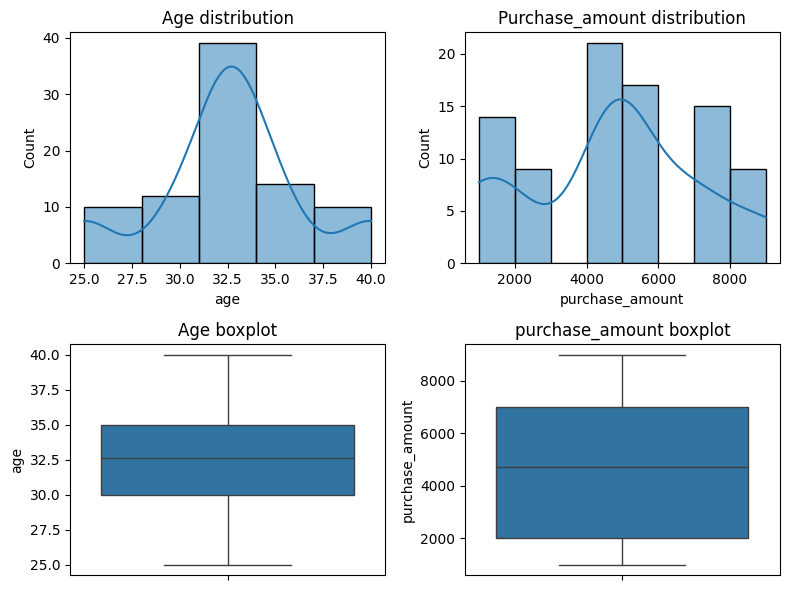

In [265]:
plt.figure(figsize = (8,6))

plt.subplot(2,2,1)
sns.histplot(df_final["age"], bins = 5, kde = True)
plt.title("Age distribution")


plt.subplot(2,2,2)
sns.histplot(df_final["purchase_amount"], kde = True)
plt.title("Purchase_amount distribution")


plt.subplot(2,2,3)
sns.boxplot(df_final["age"])
plt.title("Age boxplot")


plt.subplot(2,2,4)
sns.boxplot(df_final["purchase_amount"])
plt.title("purchase_amount boxplot")

plt.tight_layout()
plt.show()

## Perform Bivariate analysis
### Relationship between Gender and Purchase

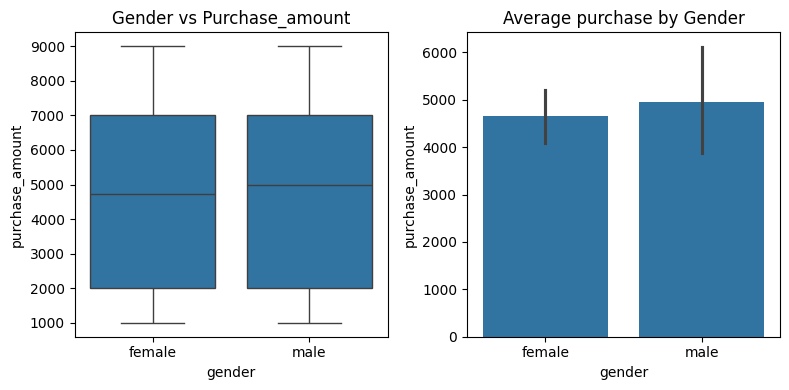

In [216]:
plt.figure(figsize = (8,4))

plt.subplot(1,2,1)
sns.boxplot(x = "gender", y = "purchase_amount", data = df_final)
plt.title("Gender vs Purchase_amount")

plt.subplot(1,2,2)
sns.barplot(x = "gender", y = "purchase_amount", data = df_final)
plt.title("Average purchase by Gender")

plt.tight_layout()
plt.show()

## Perform multivariate analysis
### correlation heatmap of all numerical variables

In [217]:
df_final["gender"] = df_final["gender"].map({
    "male" : 1,
    "female" : 0
})

In [223]:
df_final[["purchase_amount", "age", "gender"]].corr()

,purchase_amount,age,gender
purchase_amount,1.000000,-0.054086,0.050560
age,-0.054086,1.000000,0.092961
gender,0.050560,0.092961,1.000000


<Axes: >

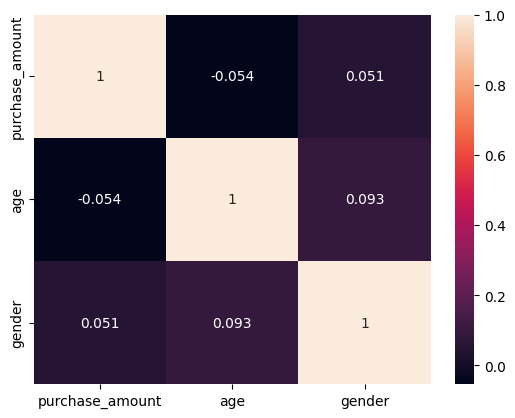

In [230]:
sns.heatmap(df_final[["purchase_amount", "age", "gender"]].corr(), annot = True)

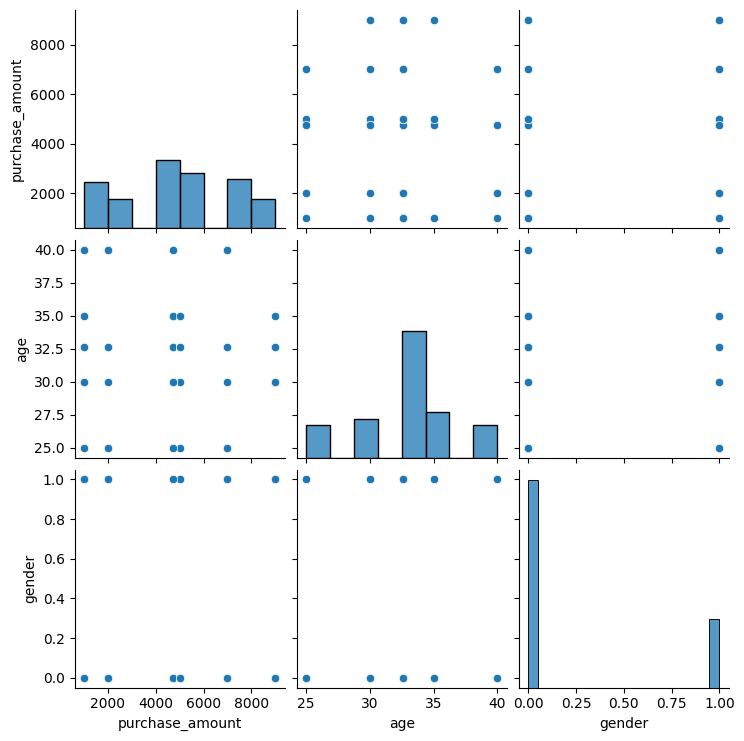

In [227]:
sns.pairplot(df_final[["purchase_amount", "age", "gender"]])

## Part E:- Data Profiling

In [232]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df_final, title="Customer Data Profiling Report")

profile.to_file("customer_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 6/6 [00:00<00:00, 75.09it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]